In [1]:
import os
import sys

import numpy as np

In [2]:
sys.path.append(os.path.join(os.getenv("CVF_PROJECT_DIR", ""), "cvf-analysis"))

utils_path = os.path.join(os.getenv("CVF_PROJECT_DIR", ""), "utils")
sys.path.append(utils_path)

from plot_graphs import plot
from command_line_helpers import get_graph

In [3]:
graph_name = "graph_17"
_, graph = next(get_graph([graph_name]))
graph

{0: {1, 2}, 1: {0, 3, 4}, 2: {0, 3, 4}, 3: {1, 2, 4}, 4: {1, 2, 3}}

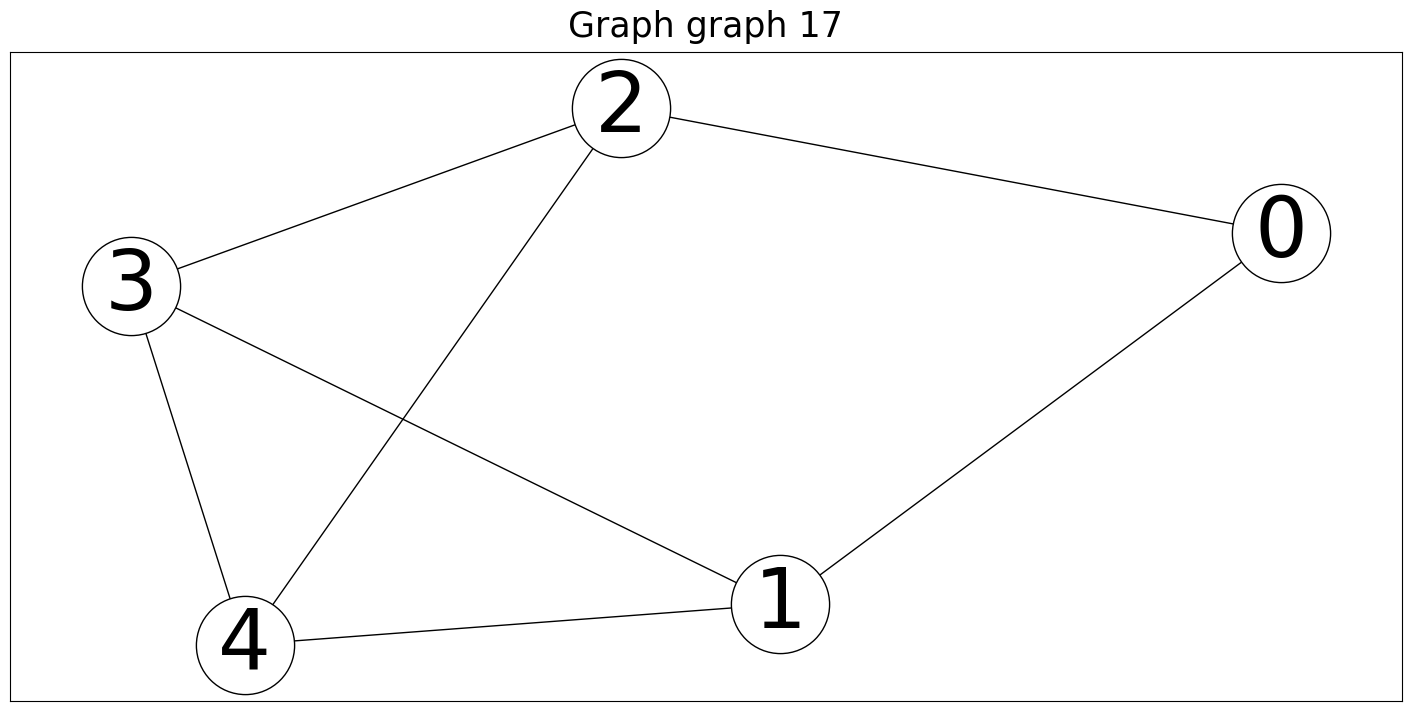

In [12]:
plot([graph_name])

# Page Rank convergence formula

$PR(P_i) = \frac{1 - d}{N} + d \sum_{P_j \in M(P_i)} \frac{PR(P_j)}{L(P_j)}$

In [5]:
d = 0.85
tol = 1e-8

In [6]:
N = len(graph)
print("No. of nodes:", N)

No. of nodes: 5


# Initial PR values

In [7]:
PR = np.full(N, 1/N)
PR

array([0.2, 0.2, 0.2, 0.2, 0.2])

# Iterations

In [8]:
itr = 1
while True:
    PR_new = []
    converged = True
    for n in range(N):
        temp = (1-d)/N + d * np.sum([ PR[nbr]/len(graph[nbr]) for nbr in graph[n] ])
        PR_new.append(temp)
        if abs(temp - PR[n]) > tol:
            converged = False
    PR = np.array(PR_new)
    if converged:
        print("Converged on the Iteration:", itr)
        break
    itr += 1


Converged on the Iteration: 41


# Page Rank scores

In [9]:
PR

array([0.15107456, 0.213661  , 0.213661  , 0.21080172, 0.21080172])

# Sorted Page Rank Scores

In [10]:
dict(sorted(enumerate(PR), key=lambda x: x[1], reverse=True))

{1: np.float64(0.21366100145750136),
 2: np.float64(0.21366100145750136),
 3: np.float64(0.21080171724682262),
 4: np.float64(0.21080171724682262),
 0: np.float64(0.15107456259135185)}

In [11]:
5**8

390625